# Task 2: Dataset Exploration

In [5]:
# Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Dataset Path
dataset_path = "/content/drive/MyDrive/part_2_cnn_computer_vision/images"

# Class Names
classes = ["normal", "scratch", "dent", "stain"]

In [3]:
#1. Number of Classes
print("Number of Classes:", len(classes))
print("Classes:", classes)

Number of Classes: 4
Classes: ['normal', 'scratch', 'dent', 'stain']


In [4]:
#2. Number of Images per Class
image_count = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(class_path))
    image_count[cls] = count

print("\nNumber of Images per Class:")

for cls, count in image_count.items():
    print(f"{cls}: {count}")

#Plot class distribution
plt.figure(figsize=(6,4))
plt.bar(image_count.keys(), image_count.values())

plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../part_2_cnn_computer_vision_dataset/images/normal'

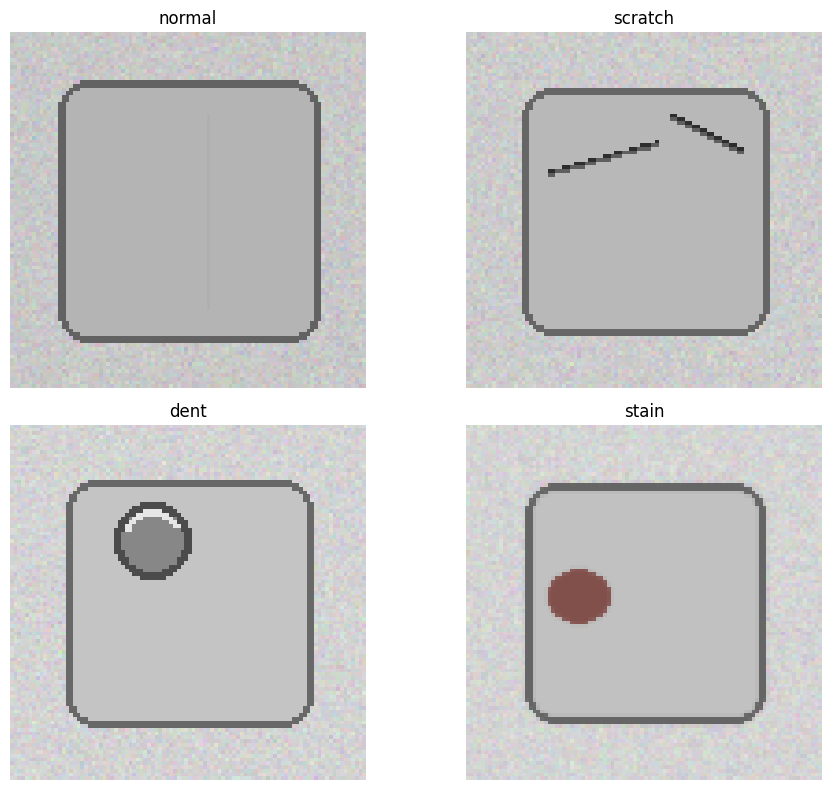

In [ ]:
#3. Display Sample Images from Each Class

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    # Read image using PIL
    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#4. Check Image Dimensions

print("\nSample Image Dimensions:")

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    print(f"{cls}: {img.size}")


Sample Image Dimensions:
normal: (96, 96)
scratch: (96, 96)
dent: (96, 96)
stain: (96, 96)


In [ ]:
#5. Check Dataset Imbalance
max_images = max(image_count.values())
min_images = min(image_count.values())

print("\nDataset Imbalance Analysis")

if max_images - min_images <= 5:
    print("Dataset is balanced.")
else:
    print("Dataset is imbalanced.")


Dataset Imbalance Analysis
Dataset is balanced.


# Task 3: Image Preprocessing

In [1]:
# Import required libraries
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Dataset Path
dataset_path = "/content/drive/MyDrive/part_2_cnn_computer_vision/images"

In [5]:
# Image Size
IMG_SIZE = 128

X = []
y = []

In [6]:
# Load, Resize and Label Images
for label, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        # Open image
        img = Image.open(img_path)

        # Convert image to RGB
        img = img.convert("RGB")

        # Resize image
        img = img.resize((IMG_SIZE, IMG_SIZE))

        # Convert image to numpy array
        img_array = np.array(img)

        X.append(img_array)
        y.append(label)

# Convert lists into numpy arrays
X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)


NameError: name 'classes' is not defined

In [ ]:




# ============================================
# Normalize Pixel Values
# ============================================

X = X / 255.0

print("\nPixel values normalized between 0 and 1")

# ============================================
# Split Dataset into Training and Testing Sets
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# ============================================
# Data Augmentation
# ============================================

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Fit augmentation on training data
train_datagen.fit(X_train)

print("\nData augmentation applied on training dataset")

# ============================================
# Observations
# ============================================

print("\nImage preprocessing completed successfully")
print("- Images resized to fixed size")
print("- Pixel values normalized")
print("- Dataset split into train and test sets")
print("- Data augmentation applied")